<a href="https://colab.research.google.com/github/dhyun16/ESAA/blob/main/%EA%B9%80%EB%91%90%ED%98%84_0918(1)_exercises_chipotle_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualizing Chipotle's Data

This time we are going to pull data directly from the internet.
Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# set this so the graphs open internally
%matplotlib inline

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv).

In [2]:
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'


### Step 3. Assign it to a variable called chipo.

In [3]:
chipo = pd.read_csv(url, sep='\t')

### Step 4. See the first 10 entries

In [4]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### Step 5. Create a histogram of the top 5 items bought

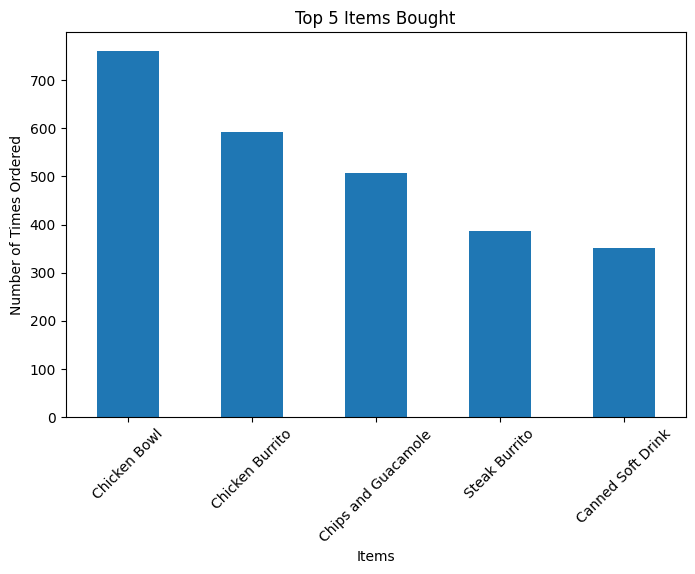

In [5]:
# 상위 5개 메뉴 추출
top_5 = chipo.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(5)

# 그래프 그리기
top_5.plot(kind='bar', figsize=(8, 5))
plt.title('Top 5 Items Bought')
plt.xlabel('Items')
plt.ylabel('Number of Times Ordered')
plt.xticks(rotation=45)
plt.show()

### Step 6. Create a scatterplot with the number of items orderered per order price
#### Hint: Price should be in the X-axis and Items ordered in the Y-axis

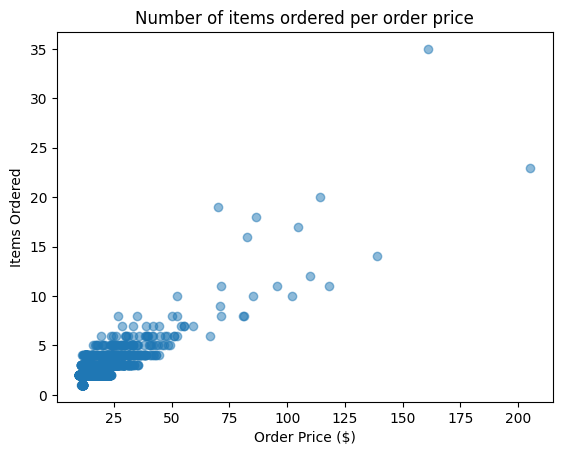

In [6]:
# item_price의 $ 제거 후 숫자형(float)으로 변환
chipo['item_price'] = chipo['item_price'].apply(lambda x: float(x[1:]) if isinstance(x, str) else x)

# 주문(order_id)별 총 가격과 총 수량 계산
orders = chipo.groupby('order_id').sum()

# 산점도 생성 (X축: 가격, Y축: 주문 수량)
plt.scatter(x=orders['item_price'], y=orders['quantity'], alpha=0.5)
plt.title('Number of items ordered per order price')
plt.xlabel('Order Price ($)')
plt.ylabel('Items Ordered')
plt.show()

### Step 7. BONUS: Create a question and a graph to answer your own question.

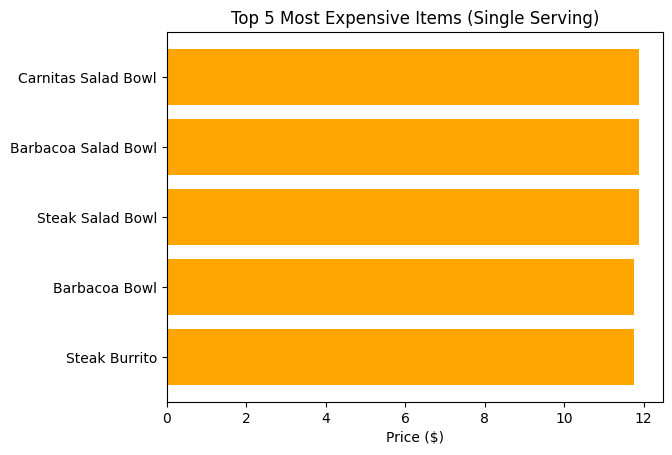

In [7]:
# 수량이 1개인 메뉴들 중 중복을 제거하고 가장 비싼 5개 확인
expensive_items = chipo[chipo['quantity'] == 1].drop_duplicates(['item_name']).sort_values('item_price', ascending=False).head(5)

# 가로 막대 그래프 그리기
plt.barh(expensive_items['item_name'], expensive_items['item_price'], color='orange')
plt.xlabel('Price ($)')
plt.title('Top 5 Most Expensive Items (Single Serving)')
plt.gca().invert_yaxis()
plt.show()